# 📈 Prediksi Harga Saham BBRI
## Studi Komparatif: LSTM vs XGBoost vs Hybrid Stacking (LSTM → XGBoost)

**Dataset:** BBRI.JK — Yahoo Finance (2015–2025)  
**Target:** Harga Penutupan (*Close Price*) t+1  
**Arsitektur Hybrid:** Output prediksi LSTM digunakan sebagai fitur tambahan untuk model XGBoost (Meta-Learner)

---
### Alur Pipeline
```
Raw Data → Preprocessing → Feature Engineering
                                    ↓
                    ┌───────────────┴───────────────┐
                 [LSTM]                         [XGBoost]
                    │                               │
             LSTM Predictions               XGBoost Predictions
                    └───────────────┬───────────────┘
                                    ↓
                          [HYBRID STACKING]
                    (LSTM Output + Lag Features → XGBoost Meta)
                                    ↓
                         Evaluation & Comparison
```

---
## 🔧 MODUL 0 — Setup & Instalasi Dependensi

In [1]:
# Install dependensi yang diperlukan
import subprocess, sys

packages = [
    'yfinance',
    'xgboost',
    'tensorflow',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'ta',           # Technical Analysis library
    'scipy'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Semua dependensi berhasil diinstal.')

✅ Semua dependensi berhasil diinstal.


In [2]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import os

# Data
import yfinance as yf

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Technical Analysis
import ta

# Stats
from scipy import stats

# Reproducibility — KUNCI: semua seed dikunci
# Reproducibility diset dinamis di MODUL CONFIG setelah run_id ditentukan

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2d3154',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'text.color': '#e0e0e0',
    'grid.color': '#2d3154',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'figure.dpi': 120
})

COLORS = {
    'actual':  '#00d4ff',
    'lstm':    '#ff6b6b',
    'xgb':     '#ffd93d',
    'hybrid':  '#6bcb77',
    'accent':  '#ff9f43'
}

print(f'✅ Library berhasil dimuat.')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   XGBoost version    : {xgb.__version__}')
# Random seed print dipindahkan ke MODUL CONFIG setelah ditentukan


✅ Library berhasil dimuat.
   TensorFlow version : 2.20.0
   XGBoost version    : 2.1.4


---
## 📥 MODUL 1 — Akuisisi & Eksplorasi Data (EDA)

In [3]:
# ============================================================
# KONFIGURASI GLOBAL EKSPERIMEN
# ============================================================
CONFIG = {
    'run_id':        10,           # default run 1 (dapat diubah 1-10)
    'ticker':        'BBRI.JK',
    'start_date':    '2015-01-01',
    'end_date':      '2025-12-31',
    'window_size':   60,          # Jumlah hari historis sebagai input sequence
    'train_ratio':   0.80,        # 80% train, 20% test (kronologis)
    'target_col':    'Close',
    # LSTM Config
    'lstm_units':    [128, 64],   # Unit per layer LSTM
    'lstm_dropout':  0.2,
    'lstm_epochs':   100,
    'lstm_batch':    32,
    'lstm_lr':       0.001,
    # XGBoost Config
    'xgb_n_estimators': 500,
    'xgb_lr':        0.05,
    'xgb_max_depth': 6,
    'xgb_subsample': 0.8,
    'xgb_colsample': 0.8,
}

OUTPUT_DIR = f"../06-output/run-{CONFIG['run_id']}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📂 Folder output diatur ke: {OUTPUT_DIR}")

# Reproducibility — KUNCI: seed disesuaikan berdasarkan run_id agar hasil bervariasi tapi tetap konsisten per run
RANDOM_SEED = 42 + CONFIG['run_id']
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
print(f"🔑 Random Seed diatur ke: {RANDOM_SEED} (locked per run)")

print('📋 Konfigurasi Eksperimen:')
for k, v in CONFIG.items():
    print(f'   {k:<22}: {v}')

📂 Folder output diatur ke: ../06-output/run-10
🔑 Random Seed diatur ke: 52 (locked per run)
📋 Konfigurasi Eksperimen:
   run_id                : 10
   ticker                : BBRI.JK
   start_date            : 2015-01-01
   end_date              : 2025-12-31
   window_size           : 60
   train_ratio           : 0.8
   target_col            : Close
   lstm_units            : [128, 64]
   lstm_dropout          : 0.2
   lstm_epochs           : 100
   lstm_batch            : 32
   lstm_lr               : 0.001
   xgb_n_estimators      : 500
   xgb_lr                : 0.05
   xgb_max_depth         : 6
   xgb_subsample         : 0.8
   xgb_colsample         : 0.8


In [4]:
# ============================================================
# DOWNLOAD DATA BBRI DARI YAHOO FINANCE
# ============================================================
print(f"📡 Mengunduh data {CONFIG['ticker']} dari Yahoo Finance...")

df_raw = yf.download(
    CONFIG['ticker'],
    start=CONFIG['start_date'],
    end=CONFIG['end_date'],
    progress=False
)

# Flatten MultiIndex columns jika ada
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw.index = pd.to_datetime(df_raw.index)
df_raw = df_raw.sort_index()

print(f'✅ Data berhasil diunduh!')
print(f'   Periode   : {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'   Total baris: {len(df_raw):,} hari perdagangan')
print(f'   Kolom      : {list(df_raw.columns)}')
print()
df_raw.tail()

📡 Mengunduh data BBRI.JK dari Yahoo Finance...


✅ Data berhasil diunduh!
   Periode   : 2015-01-02 → 2025-12-30
   Total baris: 2,711 hari perdagangan
   Kolom      : ['Close', 'High', 'Low', 'Open', 'Volume']



Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-22,3403.562744,3421.666801,3394.510716,3412.614773,161680300
2025-12-23,3412.614746,3421.666775,3376.406632,3403.562718,138427000
2025-12-24,3412.614746,3430.718803,3394.510689,3412.614746,121073600
2025-12-29,3421.666504,3430.718532,3403.562448,3421.666504,238061500
2025-12-30,3437.633789,3465.811115,3428.241347,3465.811115,274402200


In [5]:
# ============================================================
# STATISTIK DESKRIPTIF
# ============================================================
print('📊 Statistik Deskriptif:')
display(df_raw.describe().round(2))

# Cek missing values
missing = df_raw.isnull().sum()
print(f'\n🔍 Missing Values:')
print(missing)

📊 Statistik Deskriptif:


Price,Close,High,Low,Open,Volume
count,2711.00,2711.00,2711.00,2711.00,2.711000e+03
mean,2565.35,2594.95,2538.16,2567.39,1.610937e+08
std,1030.20,1040.83,1021.29,1031.25,1.057055e+08
min,889.69,897.73,854.85,862.89,0.000000e+00
25%,1708.44,1726.90,1685.66,1705.59,9.545607e+07
50%,2529.46,2557.39,2500.12,2528.23,1.342103e+08
75%,3409.39,3447.91,3372.41,3415.80,1.962717e+08
max,5216.77,5237.48,5154.67,5216.77,1.000598e+09



🔍 Missing Values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


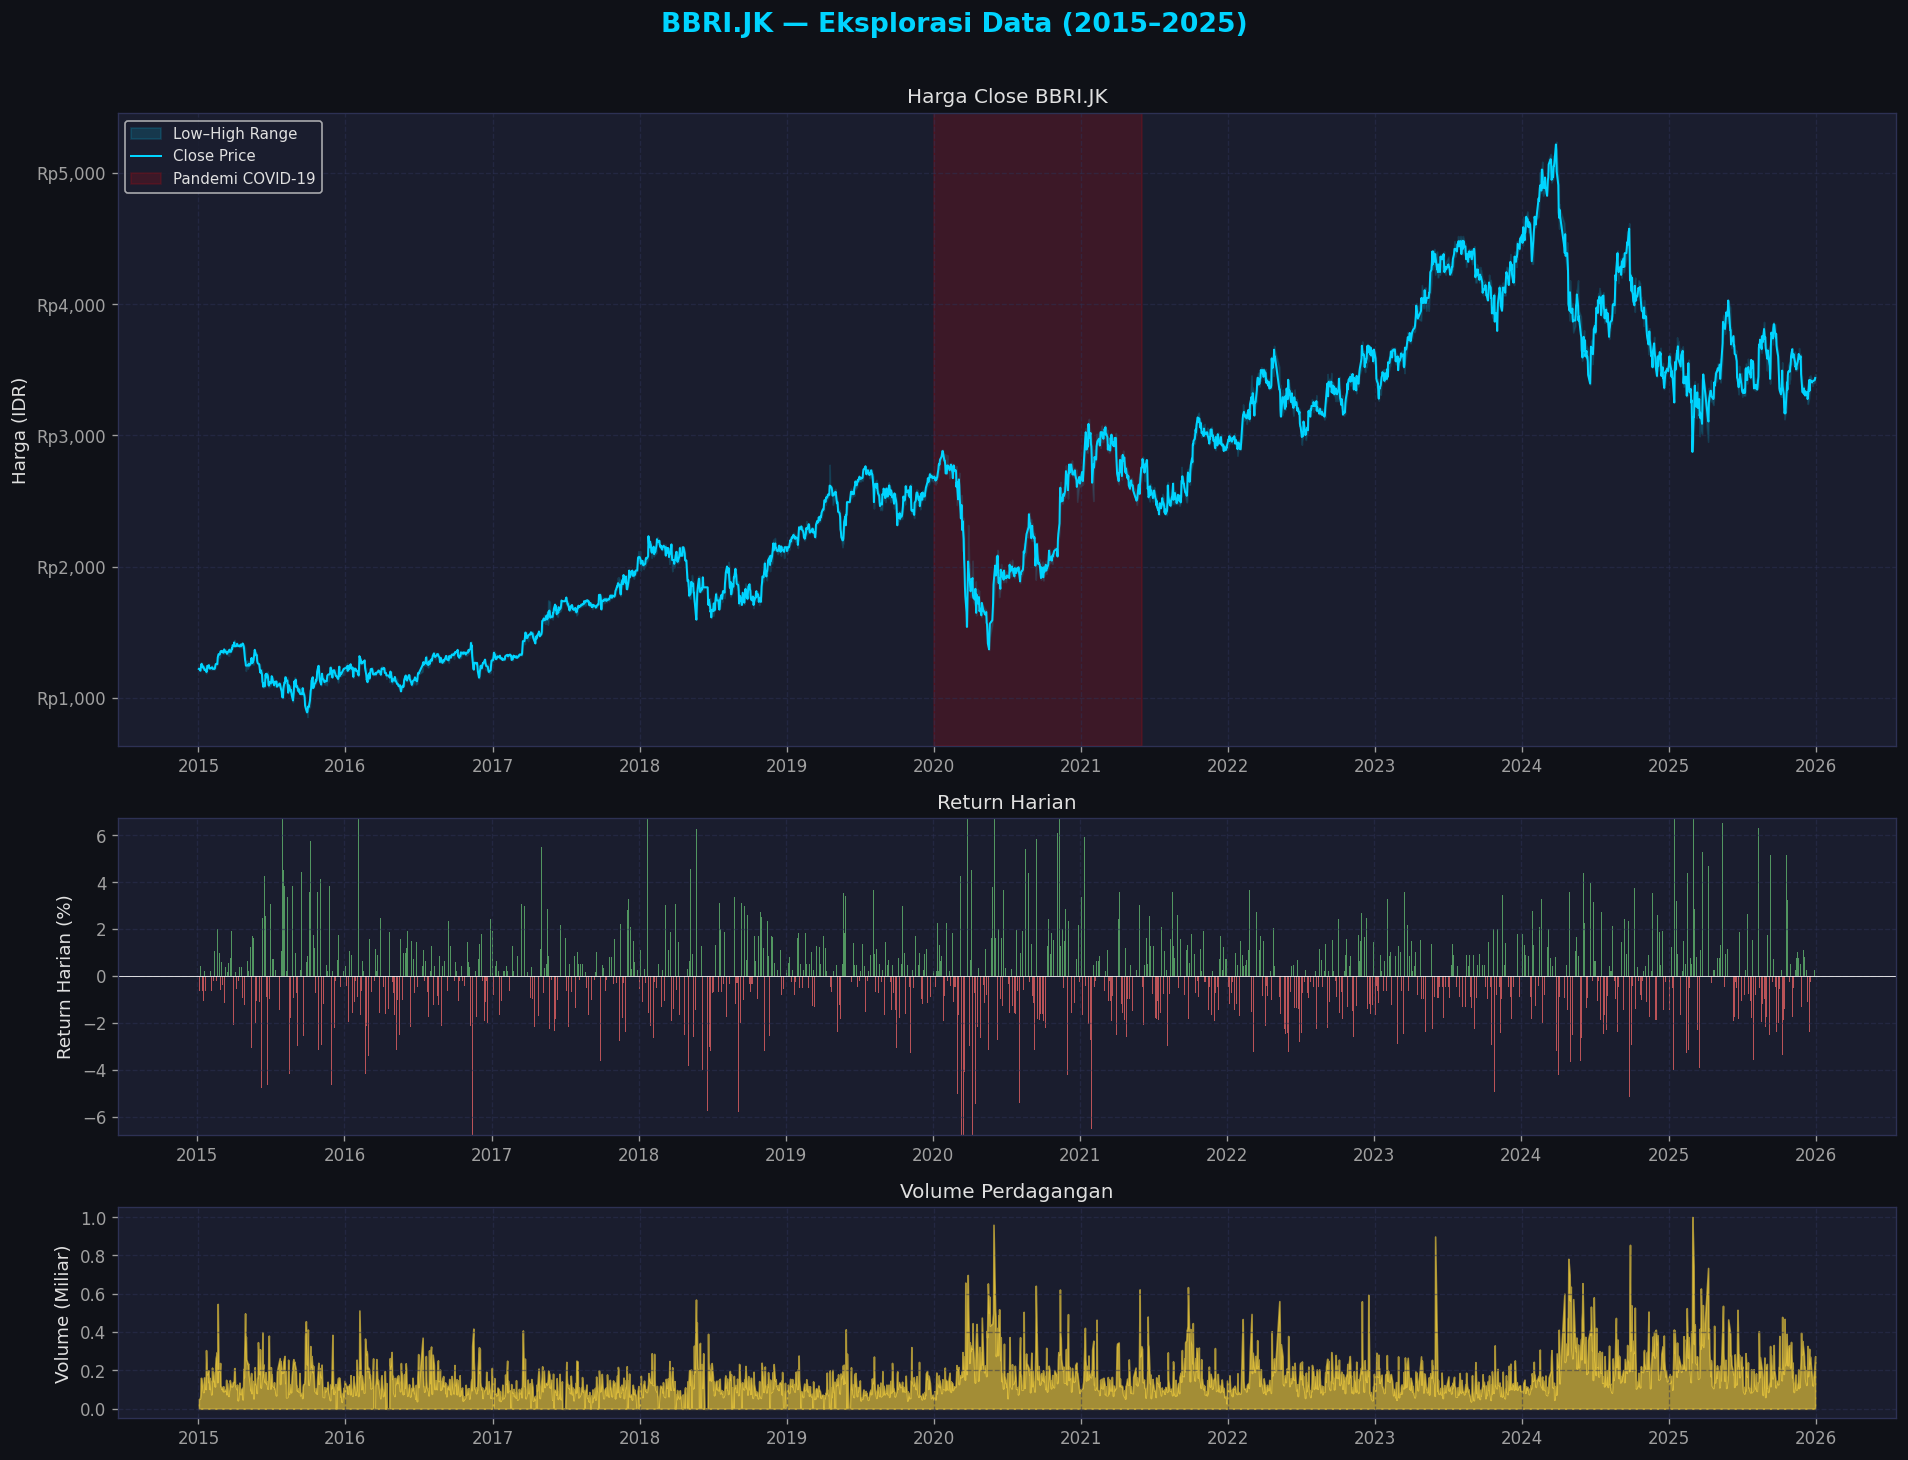

💾 Plot disimpan: ../06-output/run-10/01_eda_bbri.png


In [6]:
# ============================================================
# VISUALISASI EDA — Harga & Volume
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1.5, 1]})
fig.suptitle('BBRI.JK — Eksplorasi Data (2015–2025)', fontsize=16, fontweight='bold', color='#00d4ff', y=1.01)

# Panel 1: OHLC Candlestick simplified (Close + High + Low)
ax1 = axes[0]
ax1.fill_between(df_raw.index, df_raw['Low'], df_raw['High'], alpha=0.15, color=COLORS['actual'], label='Low–High Range')
ax1.plot(df_raw.index, df_raw['Close'], color=COLORS['actual'], linewidth=1.2, label='Close Price')
ax1.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
            alpha=0.15, color='red', label='Pandemi COVID-19')
ax1.set_ylabel('Harga (IDR)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Harga Close BBRI.JK', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
ax1.grid(True)

# Panel 2: Daily Returns
ax2 = axes[1]
returns = df_raw['Close'].pct_change() * 100
ax2.bar(df_raw.index, returns, color=np.where(returns >= 0, COLORS['hybrid'], COLORS['lstm']),
        alpha=0.7, width=1)
ax2.axhline(0, color='white', linewidth=0.5)
ax2.set_ylabel('Return Harian (%)', fontsize=11)
ax2.set_title('Return Harian', fontsize=12)
ax2.set_ylim(returns.quantile(0.005), returns.quantile(0.995))
ax2.grid(True)

# Panel 3: Volume
ax3 = axes[2]
ax3.fill_between(df_raw.index, df_raw['Volume'] / 1e9, alpha=0.6, color=COLORS['xgb'])
ax3.set_ylabel('Volume (Miliar)', fontsize=11)
ax3.set_title('Volume Perdagangan', fontsize=12)
ax3.grid(True)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_eda_bbri.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "01_eda_bbri.png")}')

---
## ⚙️ MODUL 2 — Feature Engineering & Pra-Pemrosesan

In [7]:
# ============================================================
# FEATURE ENGINEERING — Indikator Teknikal
# ============================================================
df = df_raw.copy()

# --- Trend Indicators ---
df['MA_7']    = df['Close'].rolling(7).mean()
df['MA_20']   = df['Close'].rolling(20).mean()
df['MA_50']   = df['Close'].rolling(50).mean()
df['EMA_12']  = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26']  = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']    = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# --- Momentum Indicators ---
df['RSI_14']  = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()
df['ROC_10']  = df['Close'].pct_change(10) * 100

# --- Volatility Indicators ---
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_Upper']  = bb.bollinger_hband()
df['BB_Middle'] = bb.bollinger_mavg()
df['BB_Lower']  = bb.bollinger_lband()
df['BB_Width']  = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']
df['ATR_14']    = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close'], window=14).average_true_range()

# --- Volume Indicators ---
df['OBV']       = ta.volume.OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume()
df['VWAP_Proxy'] = (df['Close'] * df['Volume']).rolling(20).sum() / df['Volume'].rolling(20).sum()

# --- Price-derived Features ---
df['Return_1d']  = df['Close'].pct_change(1)
df['Return_5d']  = df['Close'].pct_change(5)
df['Return_20d'] = df['Close'].pct_change(20)
df['HL_Ratio']   = (df['High'] - df['Low']) / df['Close']  # Daily range
df['OC_Ratio']   = (df['Close'] - df['Open']) / df['Open']  # Body ratio

# --- Target Variable: Close t+1 ---
df['Target'] = df['Close'].shift(-1)

# Drop NaN dari rolling window dan shift
df.dropna(inplace=True)

print(f'✅ Feature engineering selesai.')
print(f'   Total fitur  : {df.shape[1] - 1} (+ 1 target)')
print(f'   Total sampel : {len(df):,}')
print(f'   Periode aktif: {df.index.min().date()} → {df.index.max().date()}')

# Tampilkan daftar fitur
feature_cols = [c for c in df.columns if c != 'Target']
print(f'\n   Fitur: {feature_cols}')

✅ Feature engineering selesai.
   Total fitur  : 27 (+ 1 target)
   Total sampel : 2,661
   Periode aktif: 2015-03-13 → 2025-12-29

   Fitur: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_7', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'ROC_10', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'ATR_14', 'OBV', 'VWAP_Proxy', 'Return_1d', 'Return_5d', 'Return_20d', 'HL_Ratio', 'OC_Ratio']


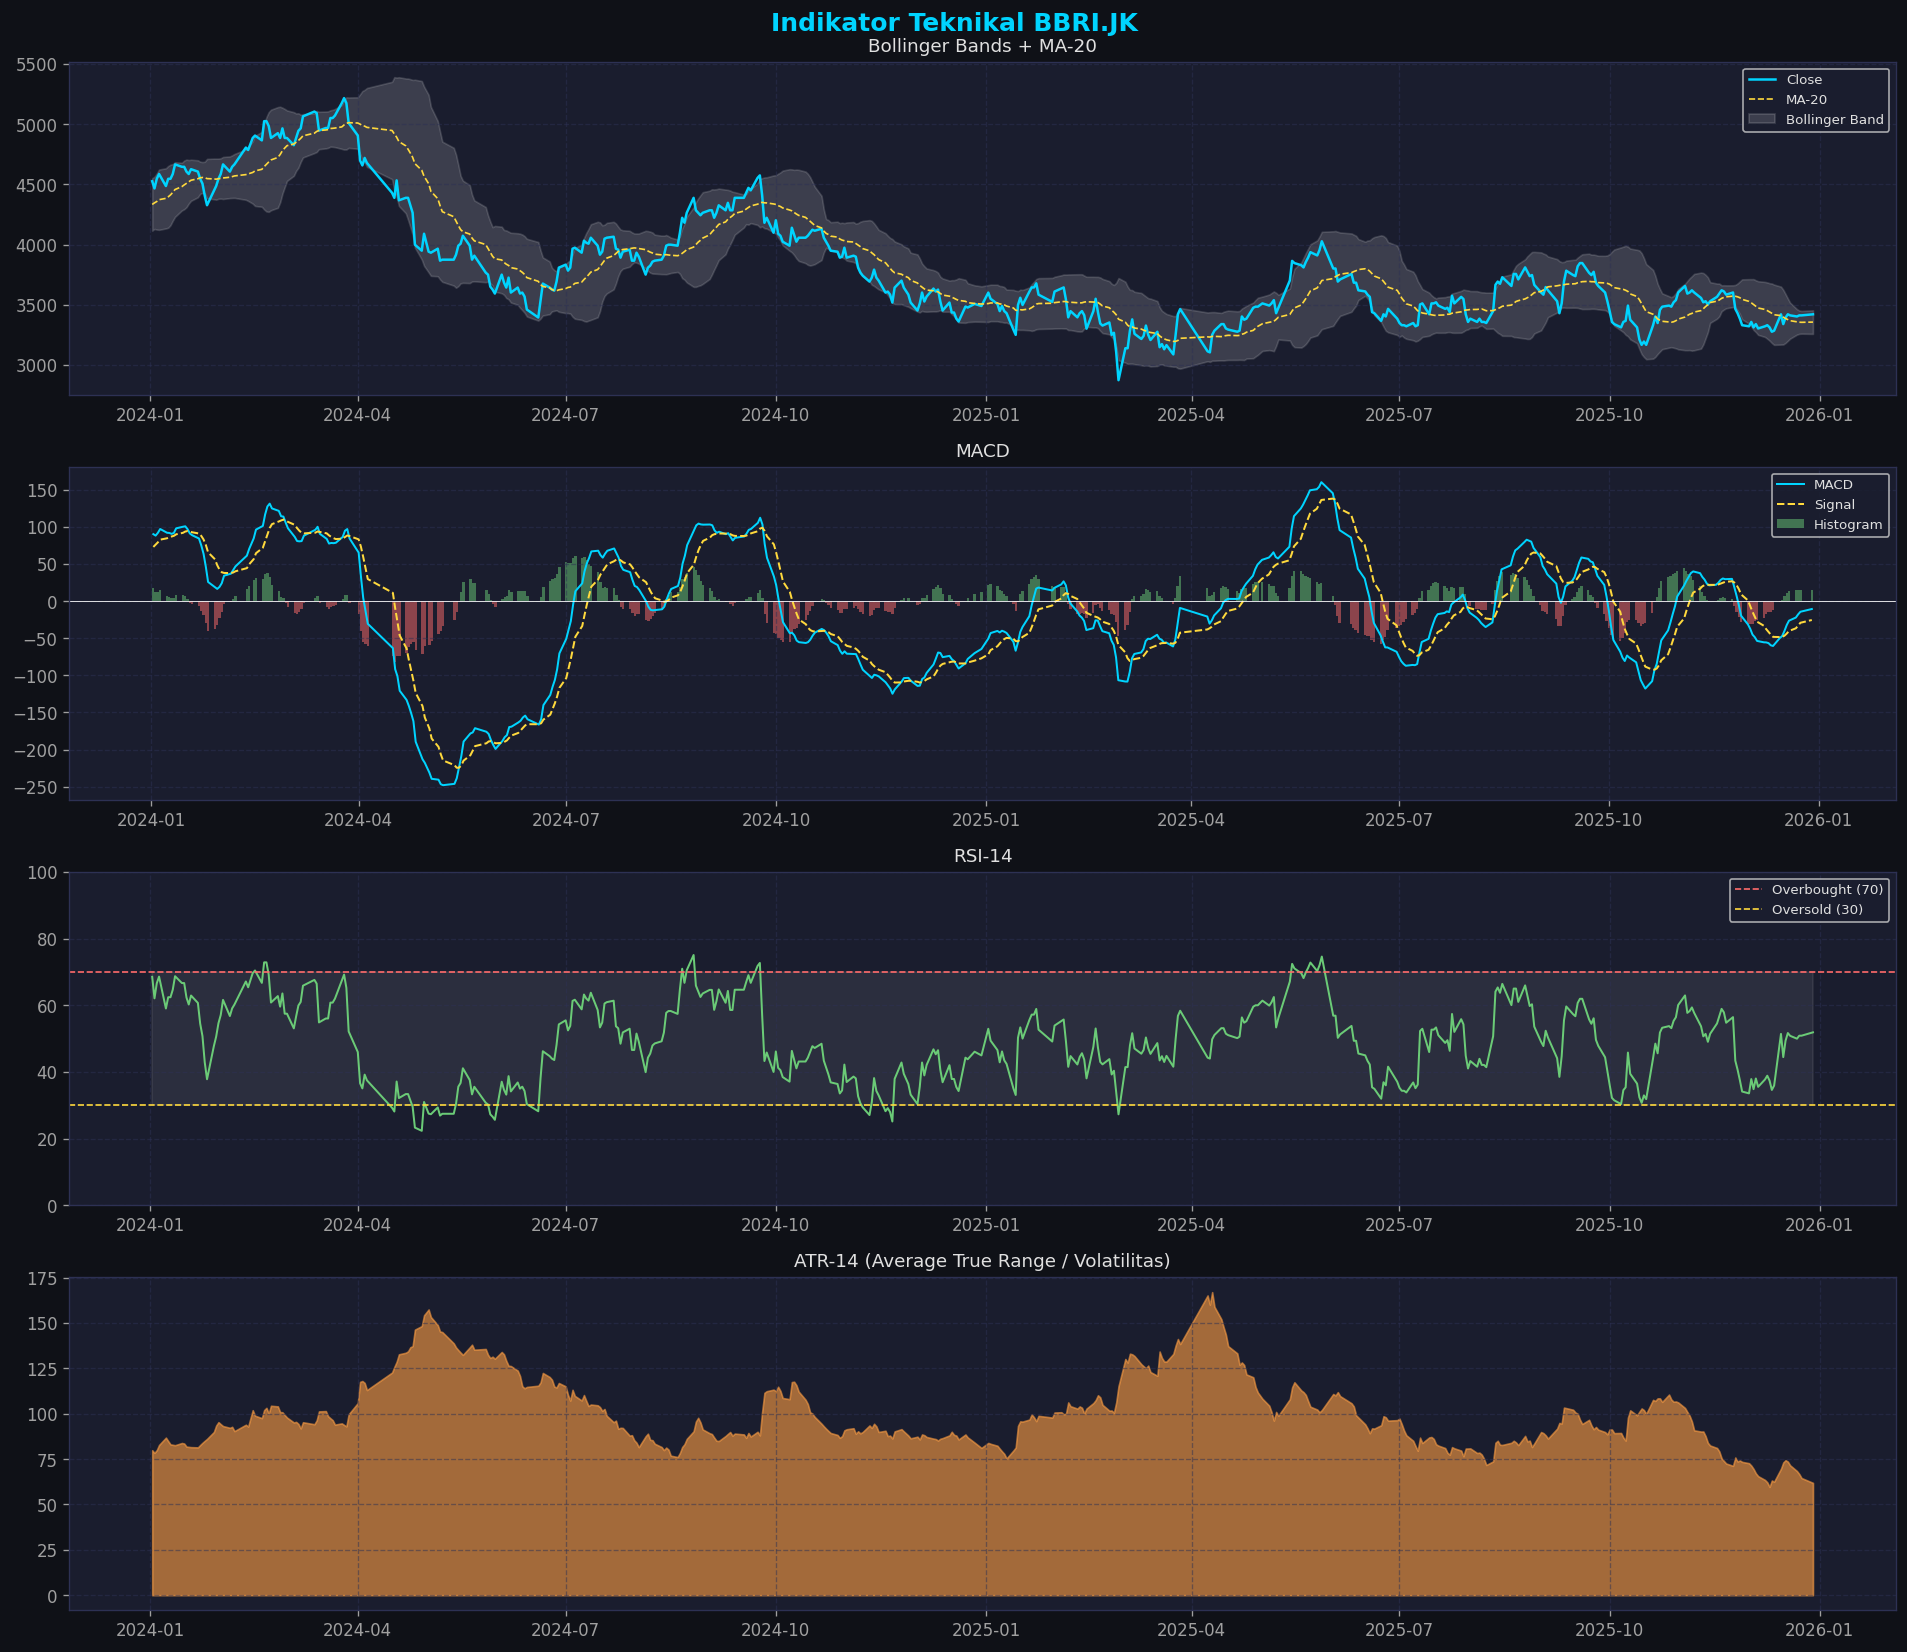

💾 Plot disimpan: ../06-output/run-10/02_technical_indicators.png


In [8]:
# ============================================================
# VISUALISASI INDIKATOR TEKNIKAL
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Indikator Teknikal BBRI.JK', fontsize=15, fontweight='bold', color='#00d4ff')

recent = df.last('730D')  # 2 tahun terakhir

# Bollinger Bands + MA
ax = axes[0]
ax.plot(recent.index, recent['Close'], color=COLORS['actual'], lw=1.5, label='Close')
ax.plot(recent.index, recent['MA_20'], color=COLORS['xgb'], lw=1, label='MA-20', linestyle='--')
ax.fill_between(recent.index, recent['BB_Lower'], recent['BB_Upper'],
                alpha=0.15, color='white', label='Bollinger Band')
ax.set_title('Bollinger Bands + MA-20', fontsize=11)
ax.legend(fontsize=8); ax.grid(True)

# MACD
ax = axes[1]
ax.plot(recent.index, recent['MACD'], color=COLORS['actual'], lw=1.2, label='MACD')
ax.plot(recent.index, recent['MACD_Signal'], color=COLORS['xgb'], lw=1.2, label='Signal', linestyle='--')
ax.bar(recent.index, recent['MACD_Hist'],
       color=np.where(recent['MACD_Hist'] >= 0, COLORS['hybrid'], COLORS['lstm']),
       alpha=0.5, width=1, label='Histogram')
ax.axhline(0, color='white', lw=0.5)
ax.set_title('MACD', fontsize=11)
ax.legend(fontsize=8); ax.grid(True)

# RSI
ax = axes[2]
ax.plot(recent.index, recent['RSI_14'], color=COLORS['hybrid'], lw=1.2)
ax.axhline(70, color=COLORS['lstm'], lw=1, linestyle='--', label='Overbought (70)')
ax.axhline(30, color=COLORS['xgb'], lw=1, linestyle='--', label='Oversold (30)')
ax.fill_between(recent.index, 30, 70, alpha=0.08, color='white')
ax.set_ylim(0, 100)
ax.set_title('RSI-14', fontsize=11)
ax.legend(fontsize=8); ax.grid(True)

# ATR
ax = axes[3]
ax.fill_between(recent.index, recent['ATR_14'], alpha=0.6, color=COLORS['accent'])
ax.set_title('ATR-14 (Average True Range / Volatilitas)', fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_technical_indicators.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "02_technical_indicators.png")}')

In [9]:
# ============================================================
# PEMBAGIAN DATA — Walk-Forward (Kronologis Ketat)
# ============================================================
feature_cols = [c for c in df.columns if c != 'Target']
target_col   = 'Target'

n = len(df)
train_end = int(n * CONFIG['train_ratio'])

df_train = df.iloc[:train_end]
df_test  = df.iloc[train_end:]

print('📂 Pembagian Data (Walk-Forward):')
print(f'   Train : {len(df_train):,} sampel | {df_train.index.min().date()} → {df_train.index.max().date()}')
print(f'   Test  : {len(df_test):,} sampel  | {df_test.index.min().date()} → {df_test.index.max().date()}')
print(f'   Rasio : {len(df_train)/n*100:.1f}% / {len(df_test)/n*100:.1f}%')
print()
print('⚠️  ANTI DATA LEAKAGE: Scaler HANYA di-fit pada data TRAIN.')

📂 Pembagian Data (Walk-Forward):
   Train : 2,128 sampel | 2015-03-13 → 2023-10-03
   Test  : 533 sampel  | 2023-10-04 → 2025-12-29
   Rasio : 80.0% / 20.0%

⚠️  ANTI DATA LEAKAGE: Scaler HANYA di-fit pada data TRAIN.


In [10]:
# ============================================================
# NORMALISASI — MinMaxScaler (fit ONLY on Train)
# ============================================================
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_raw = df_train[feature_cols].values
y_train_raw = df_train[target_col].values.reshape(-1, 1)
X_test_raw  = df_test[feature_cols].values
y_test_raw  = df_test[target_col].values.reshape(-1, 1)

# FIT pada Train, TRANSFORM pada Train & Test
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw).ravel()
y_test_scaled  = scaler_y.transform(y_test_raw).ravel()

# Nilai aktual test (rupiah asli) untuk evaluasi akhir
y_test_actual = y_test_raw.ravel()

print('✅ Normalisasi selesai (MinMax [0,1]).')
print(f'   X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}')

✅ Normalisasi selesai (MinMax [0,1]).
   X_train: (2128, 27) | X_test: (533, 27)


In [11]:
# ============================================================
# SLIDING WINDOW — Untuk Input LSTM (3D Tensor)
# ============================================================
def create_sequences(X, y, window_size):
    """Membuat sequence 3D: (samples, timesteps, features)"""
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

W = CONFIG['window_size']

# Gabung train+test lalu buat sequence (hindari boundary issue)
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all_scaled = np.concatenate([y_train_scaled, y_test_scaled])

X_seq_all, y_seq_all = create_sequences(X_all_scaled, y_all_scaled, W)

# Split ulang secara kronologis
n_train_seq = len(df_train) - W
n_test_seq  = len(df_test)

X_lstm_train = X_seq_all[:n_train_seq]
y_lstm_train = y_seq_all[:n_train_seq]
X_lstm_test  = X_seq_all[n_train_seq:n_train_seq + n_test_seq]
y_lstm_test  = y_seq_all[n_train_seq:n_train_seq + n_test_seq]

# Pastikan panjang test sesuai
y_test_actual_lstm = y_test_actual[:len(y_lstm_test)]

print(f'✅ Sliding Window (W={W}) selesai.')
print(f'   X_lstm_train : {X_lstm_train.shape}')
print(f'   X_lstm_test  : {X_lstm_test.shape}')
print(f'   Input LSTM   : {X_lstm_train.shape[1]} timesteps × {X_lstm_train.shape[2]} fitur')

✅ Sliding Window (W=60) selesai.
   X_lstm_train : (2068, 60, 27)
   X_lstm_test  : (533, 60, 27)
   Input LSTM   : 60 timesteps × 27 fitur


---
## 🧠 MODUL 3 — Model LSTM (Deep Learning)

In [12]:
# ============================================================
# ARSITEKTUR LSTM
# ============================================================
def build_lstm_model(input_shape, units=[128, 64], dropout=0.2, lr=0.001):
    """Membangun model LSTM dua-layer dengan regularisasi Dropout."""
    model = Sequential([
        # Layer LSTM Pertama — return sequence untuk diteruskan ke layer berikutnya
        LSTM(units[0], return_sequences=True, input_shape=input_shape,
             name='lstm_layer_1'),
        Dropout(dropout, name='dropout_1'),

        # Layer LSTM Kedua — tidak return sequence
        LSTM(units[1], return_sequences=False, name='lstm_layer_2'),
        Dropout(dropout, name='dropout_2'),

        # Dense layers
        Dense(32, activation='relu', name='dense_1'),
        Dense(1, name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='huber',   # Robust terhadap outlier, lebih baik dari MSE untuk finansial
        metrics=['mae']
    )
    return model

# Inisialisasi model
input_shape = (X_lstm_train.shape[1], X_lstm_train.shape[2])
lstm_model = build_lstm_model(
    input_shape=input_shape,
    units=CONFIG['lstm_units'],
    dropout=CONFIG['lstm_dropout'],
    lr=CONFIG['lstm_lr']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 60, 128)        │        79,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,393 (513.25 KB)

 Trainable params: 131,393 (513.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# PELATIHAN LSTM
# ============================================================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'lstm_best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print(f'🏋️ Melatih model LSTM... (max {CONFIG["lstm_epochs"]} epoch, batch {CONFIG["lstm_batch"]})')

history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=CONFIG['lstm_epochs'],
    batch_size=CONFIG['lstm_batch'],
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=False,       # PENTING: jangan shuffle time-series!
    verbose=1
)

print(f'\n✅ Pelatihan LSTM selesai pada epoch {len(history.history["loss"])}.')


🏋️ Melatih model LSTM... (max 100 epoch, batch 32)
Epoch 1/100


 1/59 ━━━━━━━━━━━━━━━━━━━━ 1:36 2s/step - loss: 0.0051 - mae: 0.0945

 3/59 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0039 - mae: 0.0796

 5/59 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0033 - mae: 0.0707

 7/59 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0029 - mae: 0.0653

...

57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.2113e-04 - mae: 0.0199

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.2907e-04 - mae: 0.0201 - val_loss: 0.0034 - val_mae: 0.0719 - learning_rate: 2.5000e-04


Epoch 38: early stopping


Restoring model weights from the end of the best epoch: 23.



✅ Pelatihan LSTM selesai pada epoch 38.


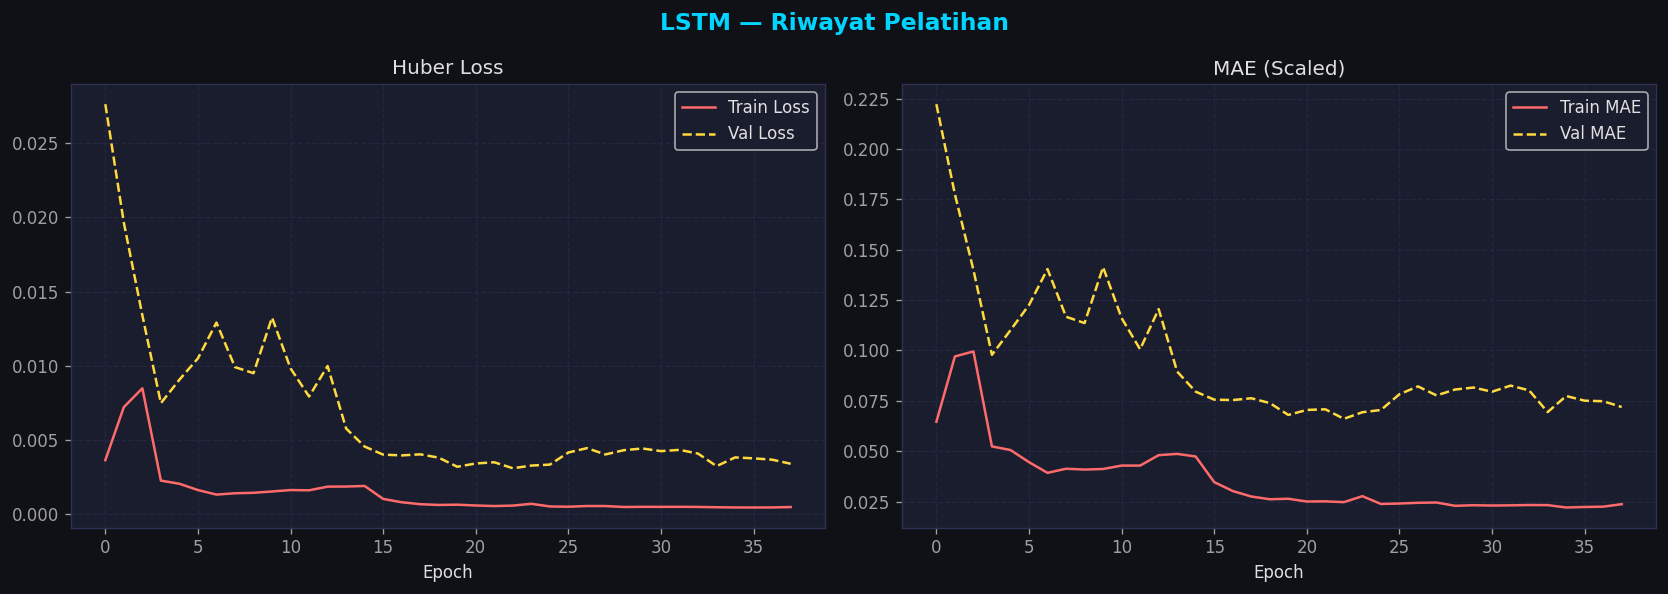

💾 Plot disimpan: ../06-output/run-10/03_lstm_training.png


In [14]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM — Riwayat Pelatihan', fontsize=14, fontweight='bold', color='#00d4ff')

ax = axes[0]
ax.plot(history.history['loss'], color=COLORS['lstm'], lw=1.5, label='Train Loss')
ax.plot(history.history['val_loss'], color=COLORS['xgb'], lw=1.5, linestyle='--', label='Val Loss')
ax.set_title('Huber Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(history.history['mae'], color=COLORS['lstm'], lw=1.5, label='Train MAE')
ax.plot(history.history['val_mae'], color=COLORS['xgb'], lw=1.5, linestyle='--', label='Val MAE')
ax.set_title('MAE (Scaled)'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_lstm_training.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "03_lstm_training.png")}')

In [15]:
# ============================================================
# PREDIKSI LSTM — Inverse Transform ke Rupiah
# ============================================================
lstm_pred_scaled_train = lstm_model.predict(X_lstm_train, verbose=0).ravel()
lstm_pred_scaled_test  = lstm_model.predict(X_lstm_test, verbose=0).ravel()

# Inverse transform
lstm_pred_train = scaler_y.inverse_transform(lstm_pred_scaled_train.reshape(-1, 1)).ravel()
lstm_pred_test  = scaler_y.inverse_transform(lstm_pred_scaled_test.reshape(-1, 1)).ravel()

# Hitung metrik LSTM
mae_lstm  = mean_absolute_error(y_test_actual_lstm, lstm_pred_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual_lstm, lstm_pred_test))
r2_lstm   = r2_score(y_test_actual_lstm, lstm_pred_test)
mape_lstm = np.mean(np.abs((y_test_actual_lstm - lstm_pred_test) / y_test_actual_lstm)) * 100

print('📊 Hasil Metrik LSTM (Test Set):')
print(f'   MAE  : Rp{mae_lstm:>12,.2f}')
print(f'   RMSE : Rp{rmse_lstm:>12,.2f}')
print(f'   R²   : {r2_lstm:.6f}')
print(f'   MAPE : {mape_lstm:.4f}%')

📊 Hasil Metrik LSTM (Test Set):
   MAE  : Rp      253.99
   RMSE : Rp      325.90
   R²   : 0.525923
   MAPE : 6.1510%


---
## 🌲 MODUL 4 — Model XGBoost (Baseline)

In [16]:
# ============================================================
# PERSIAPAN FITUR XGBoost — Lag Features Manual
# ============================================================
# XGBoost membutuhkan ekstraksi fitur temporal secara manual

def create_lag_features(X_scaled, y_scaled, window_size):
    """
    Buat fitur lag untuk XGBoost:
    - Lag t-1 s/d t-{window} untuk close price
    - Fitur teknikal pada timestep saat ini
    """
    n_features = X_scaled.shape[1]
    X_lag, y_lag = [], []

    for i in range(window_size, len(X_scaled)):
        row = []
        # Fitur saat ini (t)
        row.extend(X_scaled[i])
        # Lag harga (Close scaled) untuk t-1 hingga t-W
        # Indeks 3 = kolom 'Close' di feature_cols
        close_idx = feature_cols.index('Close')
        for lag in range(1, window_size + 1):
            row.append(X_scaled[i - lag][close_idx])
        X_lag.append(row)
        y_lag.append(y_scaled[i])

    return np.array(X_lag), np.array(y_lag)

# Bangun dataset XGBoost dari all scaled data
X_xgb_all, y_xgb_all = create_lag_features(X_all_scaled, y_all_scaled, W)

X_xgb_train = X_xgb_all[:n_train_seq]
y_xgb_train = y_xgb_all[:n_train_seq]
X_xgb_test  = X_xgb_all[n_train_seq:n_train_seq + n_test_seq]
y_xgb_test  = y_xgb_all[n_train_seq:n_train_seq + n_test_seq]

print(f'✅ Fitur lag XGBoost siap.')
print(f'   X_xgb_train : {X_xgb_train.shape}')
print(f'   X_xgb_test  : {X_xgb_test.shape}')
print(f'   Total fitur  : {X_xgb_train.shape[1]} (teknikal + {W} lag Close)')

✅ Fitur lag XGBoost siap.
   X_xgb_train : (2068, 87)
   X_xgb_test  : (533, 87)
   Total fitur  : 87 (teknikal + 60 lag Close)


In [17]:
# ============================================================
# PELATIHAN XGBoost BASELINE
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators     = CONFIG['xgb_n_estimators'],
    learning_rate    = CONFIG['xgb_lr'],
    max_depth        = CONFIG['xgb_max_depth'],
    subsample        = CONFIG['xgb_subsample'],
    colsample_bytree = CONFIG['xgb_colsample'],
    reg_alpha        = 0.01,      # L1 regularization
    reg_lambda       = 1.0,       # L2 regularization
    random_state     = RANDOM_SEED,
    tree_method      = 'hist',
    eval_metric      = 'rmse',
    early_stopping_rounds = 30,
    verbosity        = 0
)

print('🏋️ Melatih model XGBoost Baseline...')

xgb_model.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_test, y_xgb_test)],
    verbose=False
)

print(f'✅ XGBoost selesai dilatih. Best iteration: {xgb_model.best_iteration}')

🏋️ Melatih model XGBoost Baseline...


✅ XGBoost selesai dilatih. Best iteration: 251


In [18]:
# ============================================================
# PREDIKSI XGBoost BASELINE
# ============================================================
xgb_pred_scaled_test = xgb_model.predict(X_xgb_test)
xgb_pred_test = scaler_y.inverse_transform(xgb_pred_scaled_test.reshape(-1, 1)).ravel()

# Sesuaikan panjang y_test_actual
y_test_actual_xgb = y_test_actual[:len(xgb_pred_test)]

mae_xgb  = mean_absolute_error(y_test_actual_xgb, xgb_pred_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual_xgb, xgb_pred_test))
r2_xgb   = r2_score(y_test_actual_xgb, xgb_pred_test)
mape_xgb = np.mean(np.abs((y_test_actual_xgb - xgb_pred_test) / y_test_actual_xgb)) * 100

print('📊 Hasil Metrik XGBoost Baseline (Test Set):')
print(f'   MAE  : Rp{mae_xgb:>12,.2f}')
print(f'   RMSE : Rp{rmse_xgb:>12,.2f}')
print(f'   R²   : {r2_xgb:.6f}')
print(f'   MAPE : {mape_xgb:.4f}%')

📊 Hasil Metrik XGBoost Baseline (Test Set):
   MAE  : Rp      125.53
   RMSE : Rp      187.98
   R²   : 0.842273
   MAPE : 3.1267%


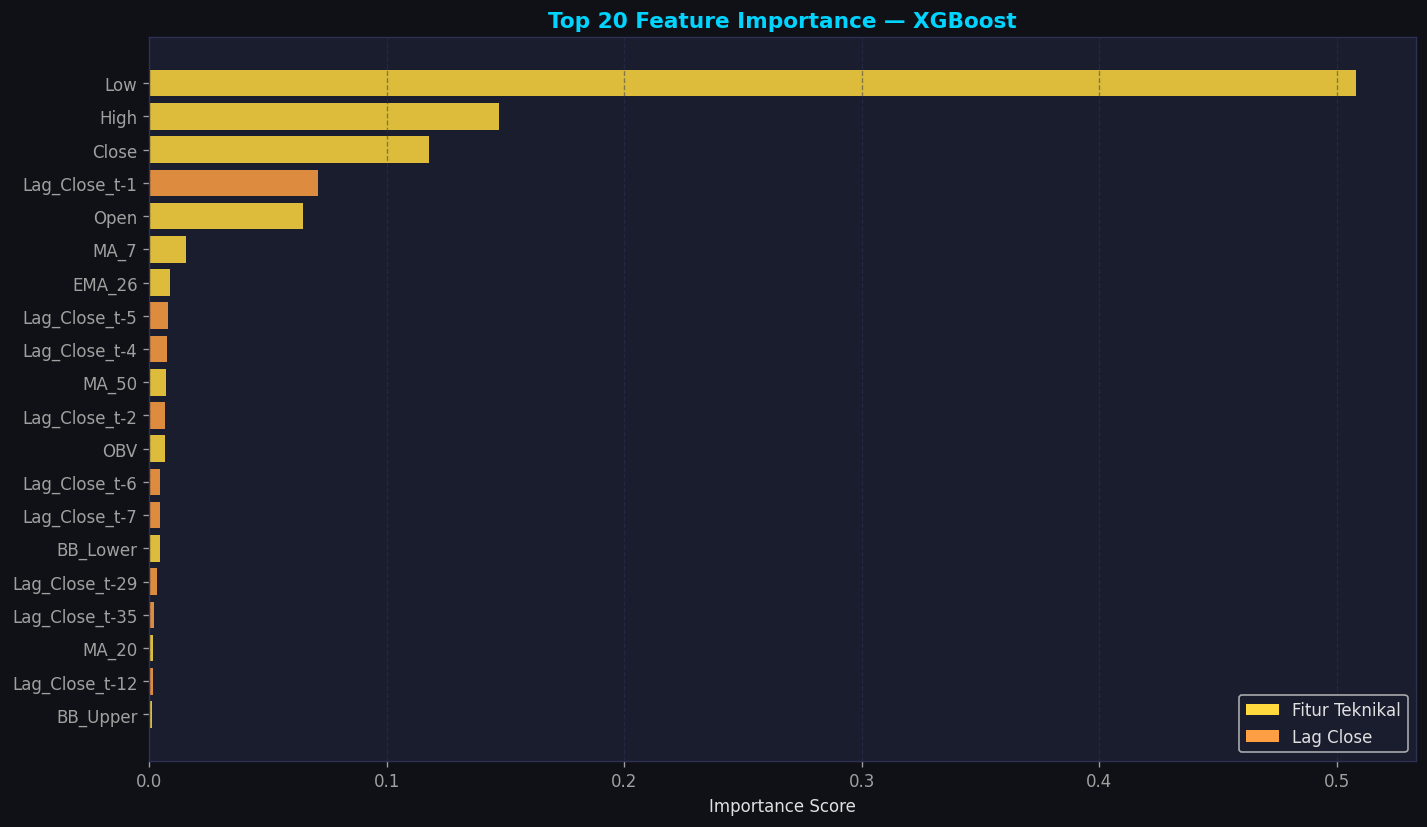

💾 Plot disimpan: ../06-output/run-10/04_xgb_feature_importance.png


In [19]:
# ============================================================
# FEATURE IMPORTANCE XGBoost
# ============================================================
importances = xgb_model.feature_importances_
n_tech = len(feature_cols)
n_lag  = W

# Nama fitur
feat_names = feature_cols + [f'Lag_Close_t-{i}' for i in range(1, W + 1)]
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = [COLORS['xgb'] if i < n_tech else COLORS['accent'] for i in top_idx]
bars = ax.barh([feat_names[i] for i in top_idx][::-1],
               importances[top_idx][::-1],
               color=colors_bar[::-1], alpha=0.85)
ax.set_title(f'Top {top_n} Feature Importance — XGBoost', fontsize=13, fontweight='bold', color='#00d4ff')
ax.set_xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['xgb'], label='Fitur Teknikal'),
                   Patch(facecolor=COLORS['accent'], label='Lag Close')]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_xgb_feature_importance.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "04_xgb_feature_importance.png")}')

---
## 🔀 MODUL 5 — Model Hybrid (LSTM → XGBoost Stacking)

In [20]:
# ============================================================
# ARSITEKTUR HYBRID STACKING
#
# Konsep:
#   Level 1 (Base Learner): LSTM → hasilkan prediksi scaled
#   Level 2 (Meta Learner): XGBoost menerima:
#       [output_LSTM_scaled] + [fitur_teknikal] + [lag_features]
#
# XGBoost Meta-Learner belajar mengoreksi bias prediksi LSTM
# ============================================================

# Prediksi LSTM (scaled) pada train dan test
lstm_pred_scaled_train_full = lstm_model.predict(X_lstm_train, verbose=0).ravel()
lstm_pred_scaled_test_full  = lstm_model.predict(X_lstm_test, verbose=0).ravel()

# Pastikan panjang sama
min_len_train = min(len(X_xgb_train), len(lstm_pred_scaled_train_full))
min_len_test  = min(len(X_xgb_test), len(lstm_pred_scaled_test_full))

# Buat fitur hybrid: [XGBoost features] + [LSTM prediction]
X_hybrid_train = np.column_stack([
    X_xgb_train[:min_len_train],
    lstm_pred_scaled_train_full[:min_len_train]
])
y_hybrid_train = y_xgb_train[:min_len_train]

X_hybrid_test = np.column_stack([
    X_xgb_test[:min_len_test],
    lstm_pred_scaled_test_full[:min_len_test]
])
y_hybrid_test = y_xgb_test[:min_len_test]

print('✅ Fitur Hybrid siap:')
print(f'   X_hybrid_train : {X_hybrid_train.shape}')
print(f'   X_hybrid_test  : {X_hybrid_test.shape}')
print(f'   Fitur tambahan : 1 (LSTM output scaled)')

✅ Fitur Hybrid siap:
   X_hybrid_train : (2068, 88)
   X_hybrid_test  : (533, 88)
   Fitur tambahan : 1 (LSTM output scaled)


In [21]:
# ============================================================
# PELATIHAN XGBoost META-LEARNER (Hybrid)
# ============================================================
xgb_hybrid = xgb.XGBRegressor(
    n_estimators     = 600,
    learning_rate    = 0.03,   # LR lebih kecil — fine-tune residual LSTM
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    reg_alpha        = 0.05,
    reg_lambda       = 1.5,
    random_state     = RANDOM_SEED,
    tree_method      = 'hist',
    eval_metric      = 'rmse',
    early_stopping_rounds = 30,
    verbosity        = 0
)

print('🏋️ Melatih XGBoost Meta-Learner (Hybrid)...')

xgb_hybrid.fit(
    X_hybrid_train, y_hybrid_train,
    eval_set=[(X_hybrid_test, y_hybrid_test)],
    verbose=False
)

print(f'✅ Hybrid selesai. Best iteration: {xgb_hybrid.best_iteration}')

🏋️ Melatih XGBoost Meta-Learner (Hybrid)...


✅ Hybrid selesai. Best iteration: 312


In [22]:
# ============================================================
# PREDIKSI HYBRID
# ============================================================
hybrid_pred_scaled = xgb_hybrid.predict(X_hybrid_test)
hybrid_pred_test = scaler_y.inverse_transform(hybrid_pred_scaled.reshape(-1, 1)).ravel()

y_test_actual_hybrid = y_test_actual[:len(hybrid_pred_test)]

mae_hybrid  = mean_absolute_error(y_test_actual_hybrid, hybrid_pred_test)
rmse_hybrid = np.sqrt(mean_squared_error(y_test_actual_hybrid, hybrid_pred_test))
r2_hybrid   = r2_score(y_test_actual_hybrid, hybrid_pred_test)
mape_hybrid = np.mean(np.abs((y_test_actual_hybrid - hybrid_pred_test) / y_test_actual_hybrid)) * 100

print('📊 Hasil Metrik Hybrid LSTM→XGBoost (Test Set):')
print(f'   MAE  : Rp{mae_hybrid:>12,.2f}')
print(f'   RMSE : Rp{rmse_hybrid:>12,.2f}')
print(f'   R²   : {r2_hybrid:.6f}')
print(f'   MAPE : {mape_hybrid:.4f}%')

📊 Hasil Metrik Hybrid LSTM→XGBoost (Test Set):
   MAE  : Rp      137.94
   RMSE : Rp      199.77
   R²   : 0.821869
   MAPE : 3.4585%


---
## 📊 MODUL 6 — Evaluasi Komparatif & Analisis Statistik

In [23]:
# ============================================================
# TABEL PERBANDINGAN METRIK
# ============================================================

# Sesuaikan panjang untuk perbandingan fair
n_eval = min(len(y_test_actual_lstm), len(y_test_actual_xgb), len(y_test_actual_hybrid))
y_true = y_test_actual[:n_eval]

# Potong semua prediksi ke panjang sama
pred_lstm   = lstm_pred_test[:n_eval]
pred_xgb    = xgb_pred_test[:n_eval]
pred_hybrid = hybrid_pred_test[:n_eval]

# Hitung ulang metrik
def compute_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': label, 'MAE (Rp)': mae, 'RMSE (Rp)': rmse, 'R²': r2, 'MAPE (%)': mape}

results = pd.DataFrame([
    compute_metrics(y_true, pred_lstm,   'LSTM'),
    compute_metrics(y_true, pred_xgb,    'XGBoost'),
    compute_metrics(y_true, pred_hybrid, 'Hybrid (LSTM→XGBoost)'),
])

results = results.set_index('Model')

print('=' * 65)
print('  📊  TABEL KOMPARASI METRIK EVALUASI MODEL')
print('=' * 65)
print(results.to_string(float_format=lambda x: f'{x:,.4f}'))
print('=' * 65)

# Temukan model terbaik
best_mae  = results['MAE (Rp)'].idxmin()
best_rmse = results['RMSE (Rp)'].idxmin()
best_r2   = results['R²'].idxmax()
best_mape = results['MAPE (%)'].idxmin()

print(f'\n🏆 Model Terbaik:')
print(f'   MAE terendah  → {best_mae}')
print(f'   RMSE terendah → {best_rmse}')
print(f'   R² tertinggi  → {best_r2}')
print(f'   MAPE terendah → {best_mape}')

results.to_csv(os.path.join(OUTPUT_DIR, 'hasil_metrik_komparasi.csv'))
print(f'\n💾 Tabel metrik disimpan: {os.path.join(OUTPUT_DIR, "hasil_metrik_komparasi.csv")}')

  📊  TABEL KOMPARASI METRIK EVALUASI MODEL
                       MAE (Rp)  RMSE (Rp)     R²  MAPE (%)
Model                                                      
LSTM                   253.9886   325.9040 0.5259    6.1510
XGBoost                125.5299   187.9825 0.8423    3.1267
Hybrid (LSTM→XGBoost)  137.9391   199.7719 0.8219    3.4585

🏆 Model Terbaik:
   MAE terendah  → XGBoost
   RMSE terendah → XGBoost
   R² tertinggi  → XGBoost
   MAPE terendah → XGBoost

💾 Tabel metrik disimpan: ../06-output/run-10/hasil_metrik_komparasi.csv


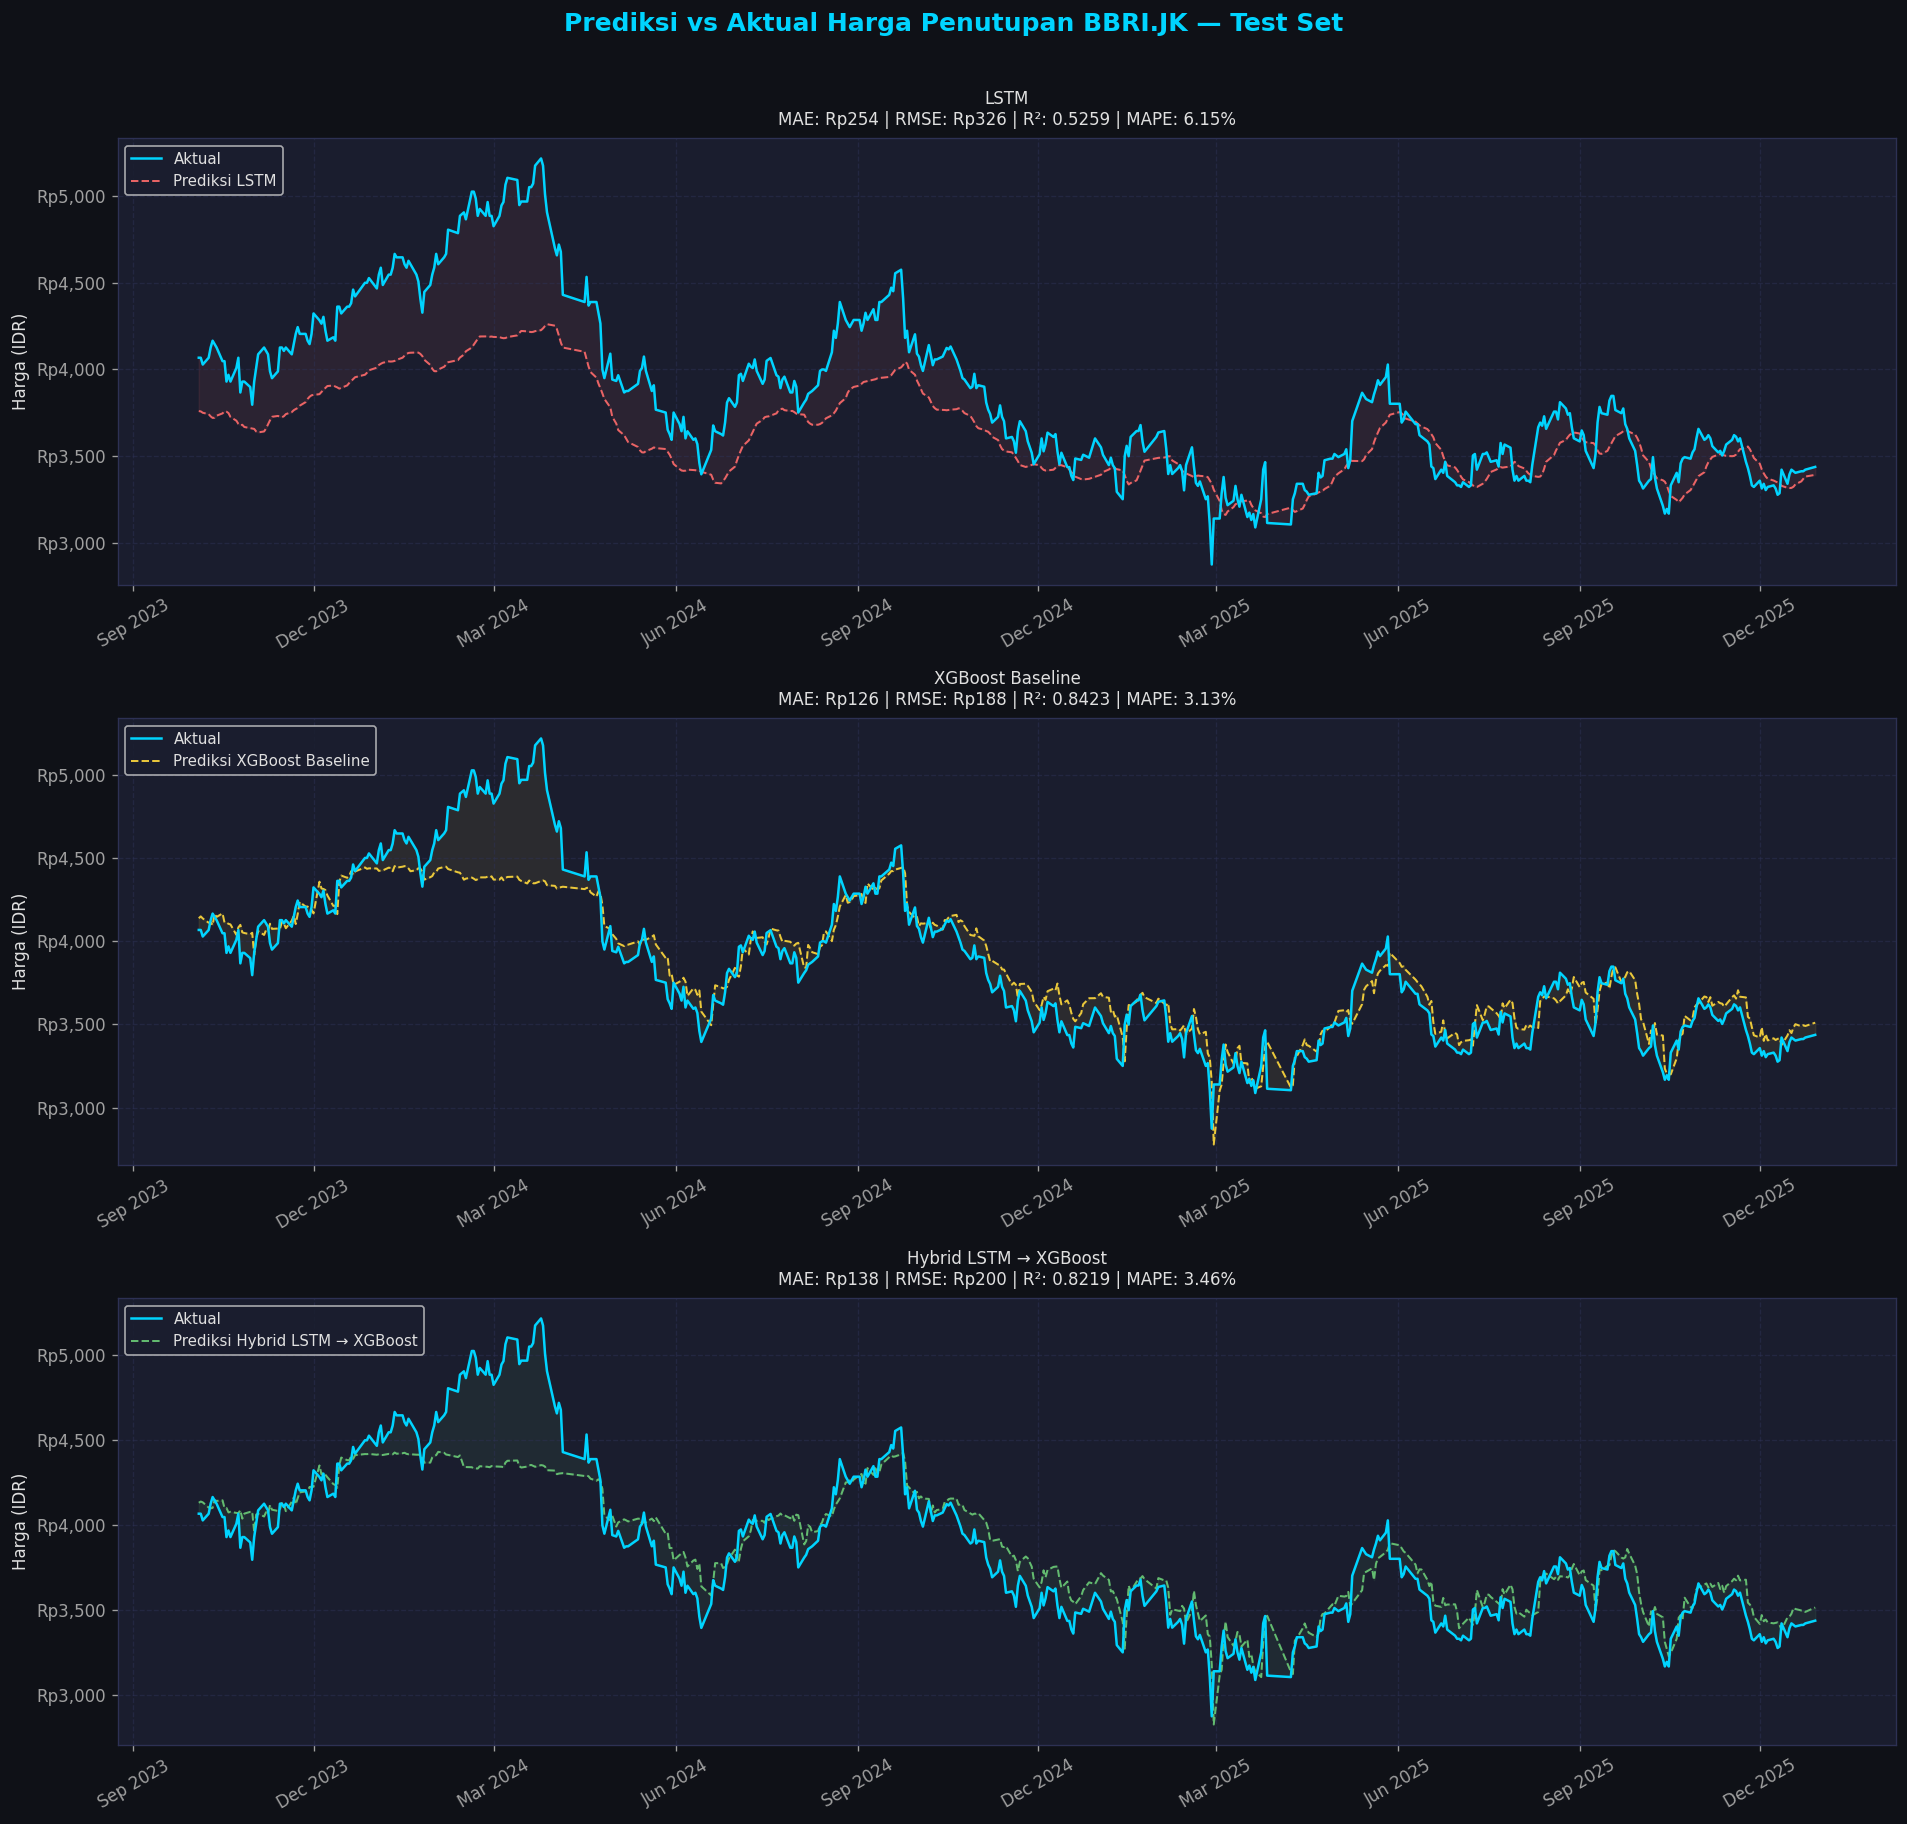

💾 Plot disimpan: ../06-output/run-10/05_prediksi_vs_aktual.png


In [24]:
# ============================================================
# VISUALISASI PREDIKSI vs AKTUAL
# ============================================================
test_dates = df_test.index[:n_eval]

fig, axes = plt.subplots(3, 1, figsize=(16, 15))
fig.suptitle('Prediksi vs Aktual Harga Penutupan BBRI.JK — Test Set',
             fontsize=15, fontweight='bold', color='#00d4ff', y=1.01)

for ax, pred, label, color in zip(
    axes,
    [pred_lstm, pred_xgb, pred_hybrid],
    ['LSTM', 'XGBoost Baseline', 'Hybrid LSTM → XGBoost'],
    [COLORS['lstm'], COLORS['xgb'], COLORS['hybrid']]
):
    ax.plot(test_dates, y_true, color=COLORS['actual'], lw=1.5, label='Aktual', zorder=3)
    ax.plot(test_dates, pred, color=color, lw=1.2, linestyle='--', label=f'Prediksi {label}', alpha=0.9)
    ax.fill_between(test_dates, y_true, pred, alpha=0.08, color=color)

    metrics = compute_metrics(y_true, pred, label)
    info = f"MAE: Rp{metrics['MAE (Rp)']:,.0f} | RMSE: Rp{metrics['RMSE (Rp)']:,.0f} | R²: {metrics['R²']:.4f} | MAPE: {metrics['MAPE (%)']:.2f}%"
    ax.set_title(f'{label}\n{info}', fontsize=10, pad=8)
    ax.set_ylabel('Harga (IDR)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_prediksi_vs_aktual.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "05_prediksi_vs_aktual.png")}')

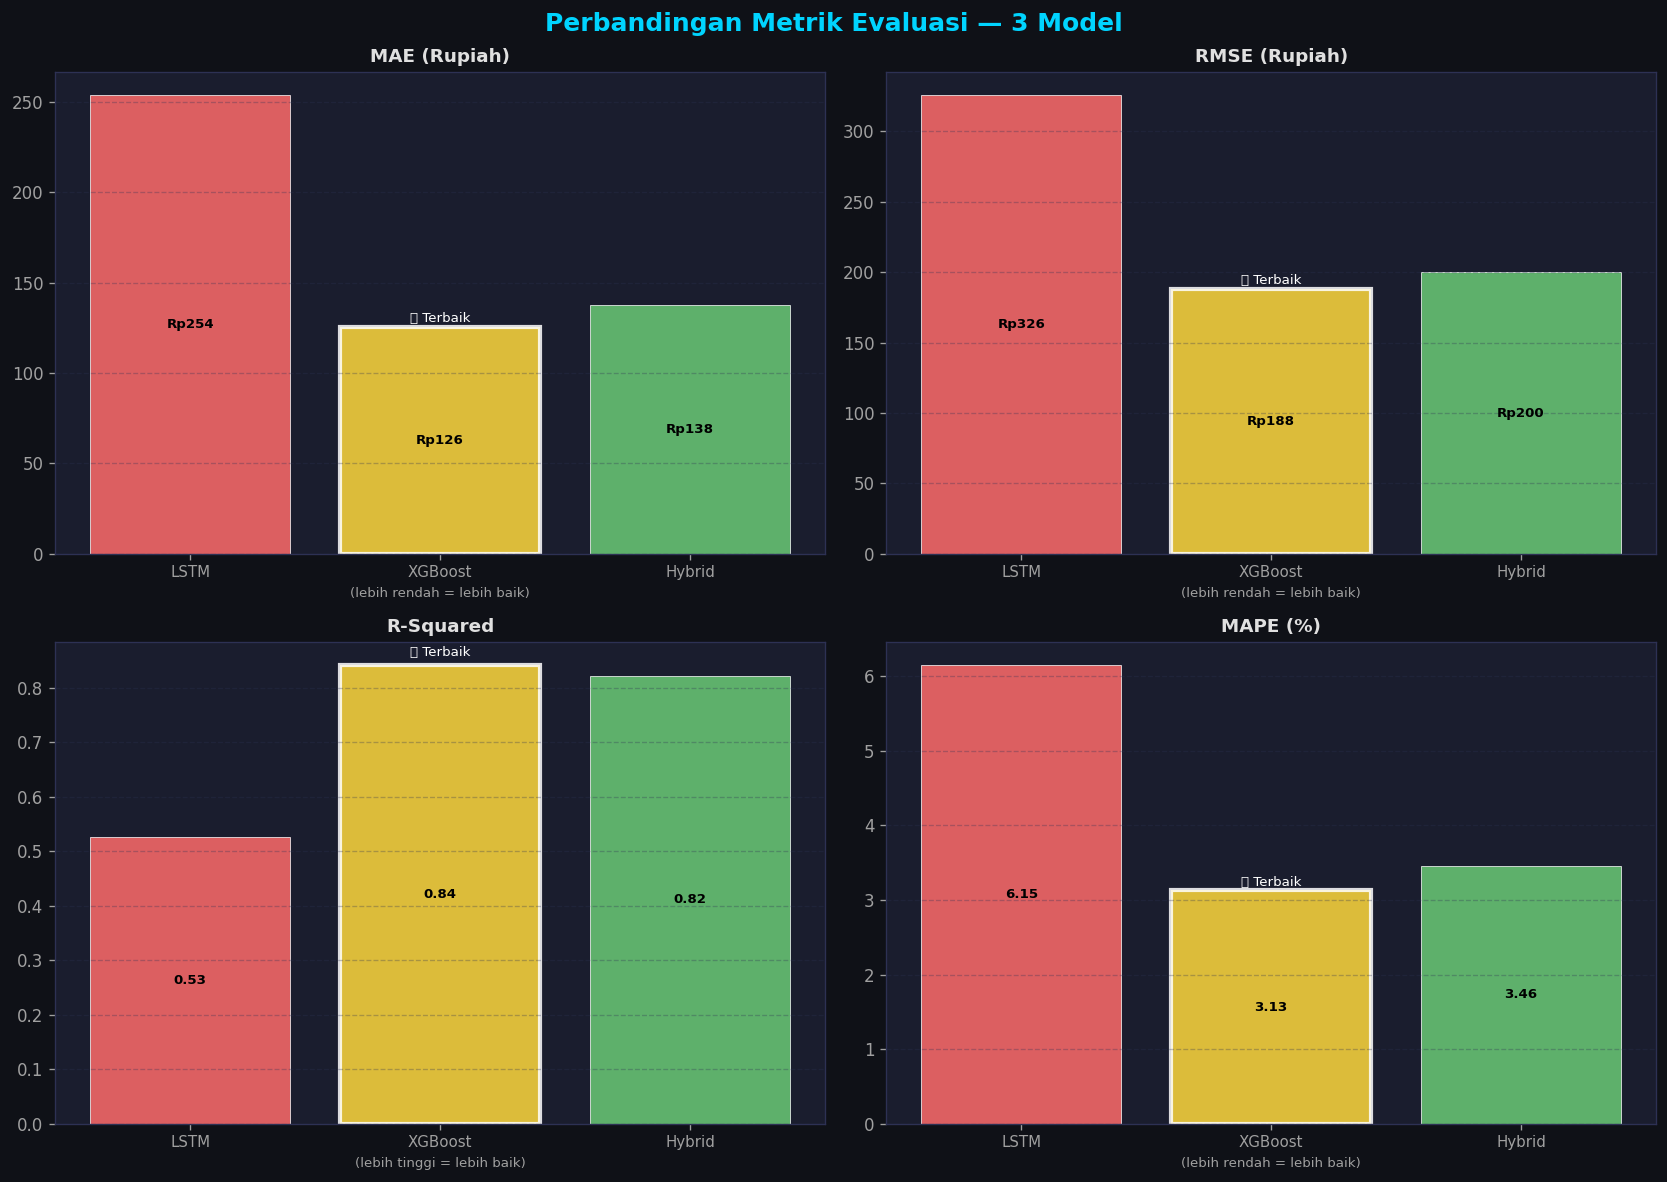

💾 Plot disimpan: ../06-output/run-10/06_komparasi_metrik.png


In [25]:
# ============================================================
# VISUALISASI PERBANDINGAN METRIK (Bar Chart)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Metrik Evaluasi — 3 Model', fontsize=15, fontweight='bold', color='#00d4ff')

models = results.index.tolist()
bar_colors = [COLORS['lstm'], COLORS['xgb'], COLORS['hybrid']]

metrics_plot = [
    ('MAE (Rp)', 'MAE (Rupiah)', True),
    ('RMSE (Rp)', 'RMSE (Rupiah)', True),
    ('R²', 'R-Squared', False),
    ('MAPE (%)', 'MAPE (%)', True),
]

for ax, (col, title, lower_better) in zip(axes.ravel(), metrics_plot):
    values = results[col].values
    bars = ax.bar(models, values, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Highlight model terbaik
    best_idx = np.argmin(values) if lower_better else np.argmax(values)
    bars[best_idx].set_edgecolor('white')
    bars[best_idx].set_linewidth(2.5)
    ax.annotate('🏆 Terbaik', xy=(best_idx, values[best_idx]),
                xytext=(best_idx, values[best_idx] * 1.02),
                ha='center', fontsize=8, color='white')

    # Nilai di atas bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 0.5,
                f'{val:,.2f}' if col != 'MAE (Rp)' and col != 'RMSE (Rp)' else f'Rp{val:,.0f}',
                ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['LSTM', 'XGBoost', 'Hybrid'], fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    note = '(lebih rendah = lebih baik)' if lower_better else '(lebih tinggi = lebih baik)'
    ax.set_xlabel(note, fontsize=8, color='#a0a0a0')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_komparasi_metrik.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "06_komparasi_metrik.png")}')

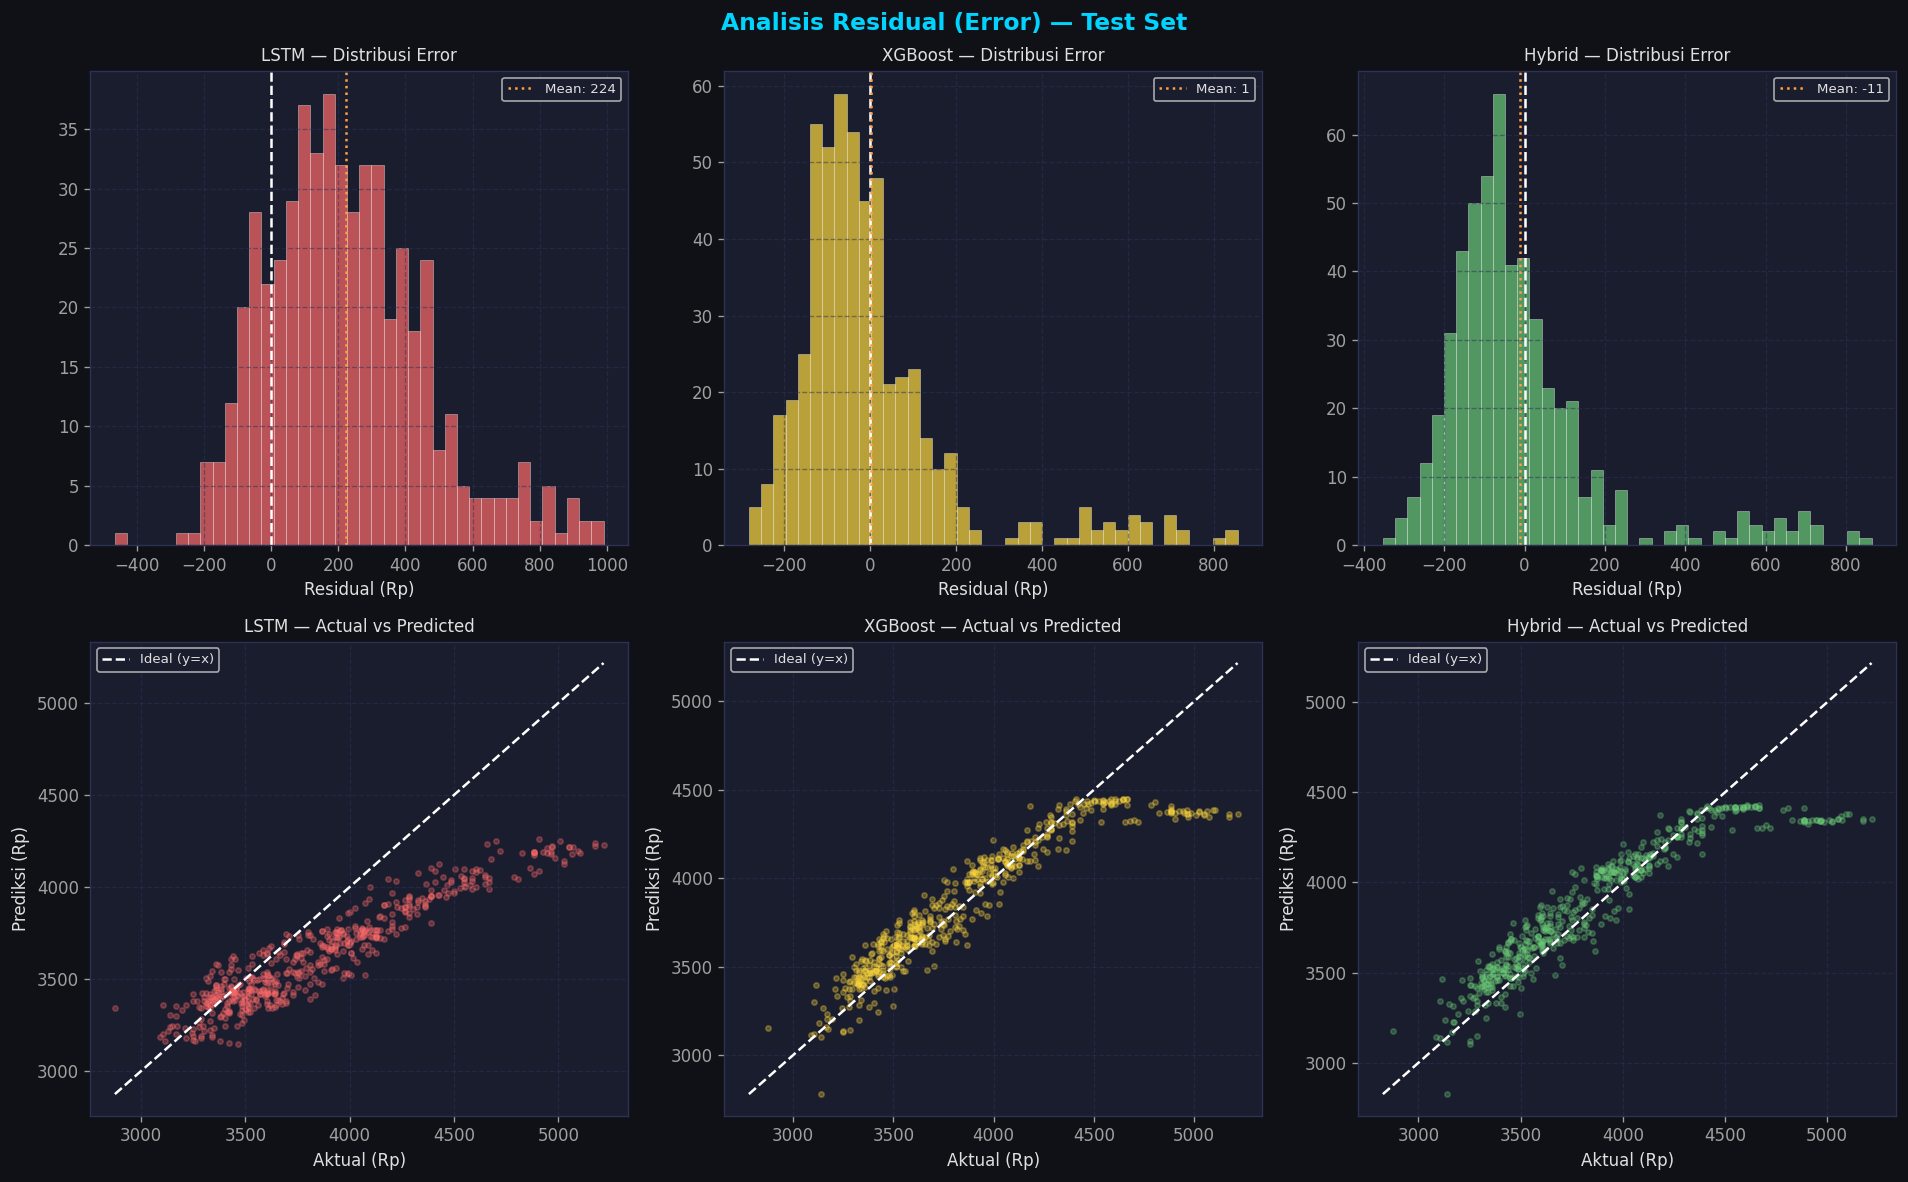

💾 Plot disimpan: ../06-output/run-10/07_analisis_residual.png


In [26]:
# ============================================================
# ANALISIS RESIDUAL — Error Distribution
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analisis Residual (Error) — Test Set', fontsize=14, fontweight='bold', color='#00d4ff')

models_data = [
    ('LSTM', pred_lstm, COLORS['lstm']),
    ('XGBoost', pred_xgb, COLORS['xgb']),
    ('Hybrid', pred_hybrid, COLORS['hybrid'])
]

for col, (label, pred, color) in enumerate(models_data):
    residuals = y_true - pred

    # Histogram residual
    ax = axes[0, col]
    ax.hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='white', lw=1.5, linestyle='--')
    ax.axvline(residuals.mean(), color=COLORS['accent'], lw=1.5, linestyle=':', label=f'Mean: {residuals.mean():.0f}')
    ax.set_title(f'{label} — Distribusi Error', fontsize=10)
    ax.set_xlabel('Residual (Rp)'); ax.legend(fontsize=8); ax.grid(True)

    # Scatter: Actual vs Predicted
    ax = axes[1, col]
    ax.scatter(y_true, pred, alpha=0.3, color=color, s=10)
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'w--', lw=1.5, label='Ideal (y=x)')
    ax.set_title(f'{label} — Actual vs Predicted', fontsize=10)
    ax.set_xlabel('Aktual (Rp)'); ax.set_ylabel('Prediksi (Rp)')
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '07_analisis_residual.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "07_analisis_residual.png")}')

In [27]:
# ============================================================
# UJI SIGNIFIKANSI STATISTIK
# Diebold-Mariano Test (adaptasi) & Wilcoxon Signed-Rank Test
# H0: Tidak ada perbedaan signifikan antara dua model
# H1: Terdapat perbedaan signifikan (α = 0.05)
# ============================================================
from scipy.stats import wilcoxon

# Hitung squared errors per prediksi
se_lstm   = (y_true - pred_lstm) ** 2
se_xgb    = (y_true - pred_xgb) ** 2
se_hybrid = (y_true - pred_hybrid) ** 2

alpha = 0.05
COMPARISONS = [
    ('LSTM vs XGBoost',   se_lstm,   se_xgb),
    ('Hybrid vs LSTM',    se_hybrid, se_lstm),
    ('Hybrid vs XGBoost', se_hybrid, se_xgb),
]

print('=' * 65)
print('  🔬  UJI SIGNIFIKANSI STATISTIK (Wilcoxon Signed-Rank Test)')
print(f'  α = {alpha} (two-tailed)')
print('=' * 65)

stat_results = []
for name, e1, e2 in COMPARISONS:
    diff = e1 - e2
    # Skip jika semua diff = 0
    if np.all(diff == 0):
        stat_results.append({'Komparasi': name, 'Statistic': 0, 'p-value': 1.0, 'Kesimpulan': 'Identik'})
        continue
    stat, pval = wilcoxon(diff, alternative='two-sided')
    kesimpulan = 'SIGNIFIKAN ✅' if pval < alpha else 'Tidak Signifikan ❌'
    stat_results.append({'Komparasi': name, 'Statistic': stat, 'p-value': pval, 'Kesimpulan': kesimpulan})
    print(f'  {name}')
    print(f'    Statistic : {stat:.4f}')
    print(f'    p-value   : {pval:.6f}')
    print(f'    Kesimpulan: {kesimpulan}')
    print()

df_stat = pd.DataFrame(stat_results)
df_stat.to_csv(os.path.join(OUTPUT_DIR, 'hasil_uji_statistik.csv'), index=False)
print(f'💾 Hasil uji statistik disimpan: {os.path.join(OUTPUT_DIR, "hasil_uji_statistik.csv")}')

  🔬  UJI SIGNIFIKANSI STATISTIK (Wilcoxon Signed-Rank Test)
  α = 0.05 (two-tailed)
  LSTM vs XGBoost
    Statistic : 20659.0000
    p-value   : 0.000000
    Kesimpulan: SIGNIFIKAN ✅

  Hybrid vs LSTM
    Statistic : 25291.0000
    p-value   : 0.000000
    Kesimpulan: SIGNIFIKAN ✅

  Hybrid vs XGBoost
    Statistic : 34882.0000
    p-value   : 0.000000
    Kesimpulan: SIGNIFIKAN ✅

💾 Hasil uji statistik disimpan: ../06-output/run-10/hasil_uji_statistik.csv


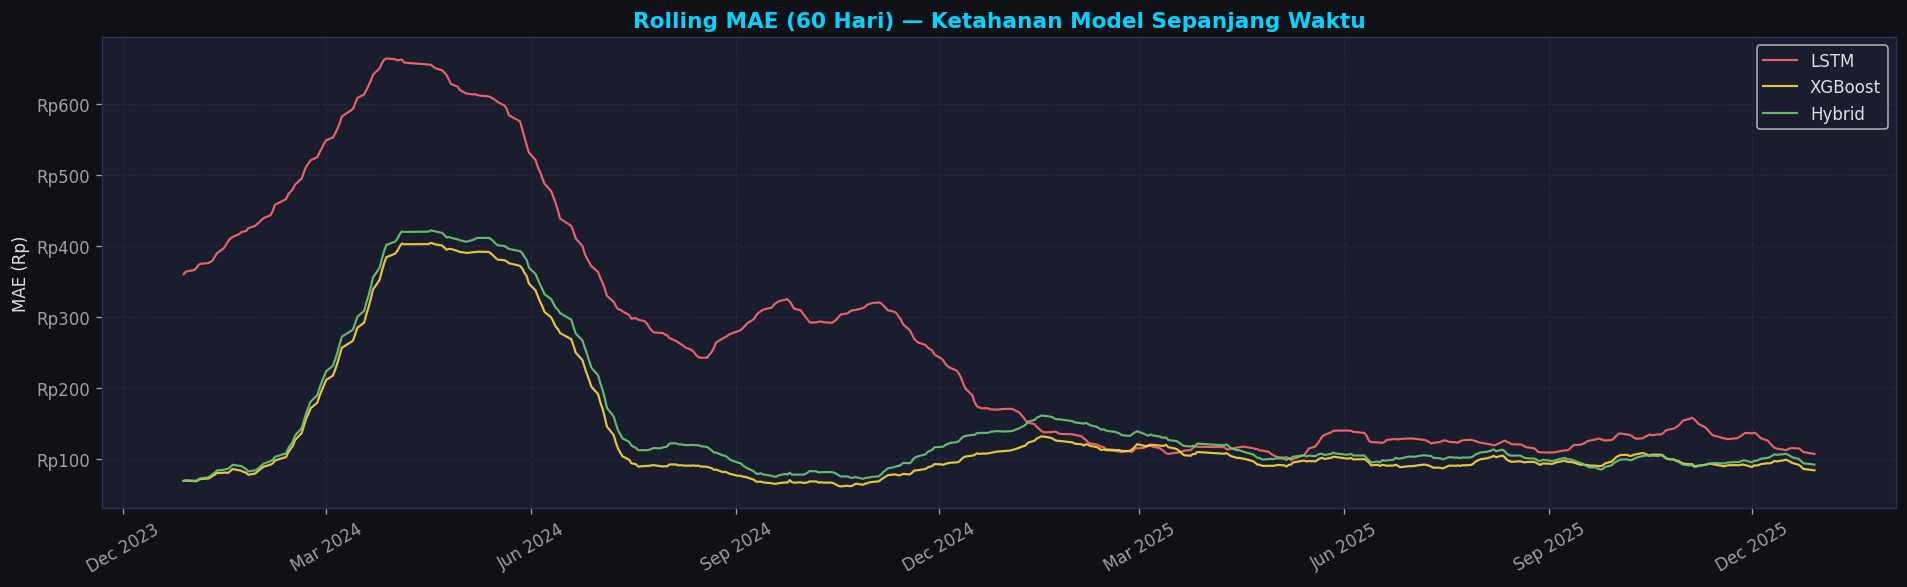

💾 Plot disimpan: ../06-output/run-10/08_rolling_mae.png


In [28]:
# ============================================================
# ROLLING WINDOW ERROR — Ketahanan Model Terhadap Waktu
# ============================================================
window_roll = 60  # hari

def rolling_mae(y_true, y_pred, window):
    errors = np.abs(y_true - y_pred)
    return pd.Series(errors).rolling(window).mean().values

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_title(f'Rolling MAE ({window_roll} Hari) — Ketahanan Model Sepanjang Waktu',
             fontsize=13, fontweight='bold', color='#00d4ff')

for label, pred, color in models_data:
    roll = rolling_mae(y_true, pred, window_roll)
    ax.plot(test_dates[:n_eval], roll, color=color, lw=1.3, label=label, alpha=0.9)

ax.set_ylabel('MAE (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_rolling_mae.png'), bbox_inches='tight', dpi=150, facecolor='#0f1117')
plt.show()
print(f'💾 Plot disimpan: {os.path.join(OUTPUT_DIR, "08_rolling_mae.png")}')

---
## 💾 MODUL 7 — Export Hasil & Ringkasan Eksperimen

In [29]:
# ============================================================
# EXPORT HASIL PREDIKSI KE CSV
# ============================================================
df_hasil = pd.DataFrame({
    'Date':          test_dates[:n_eval],
    'Actual_Close':  y_true,
    'Pred_LSTM':     pred_lstm,
    'Pred_XGBoost':  pred_xgb,
    'Pred_Hybrid':   pred_hybrid,
    'Error_LSTM':    y_true - pred_lstm,
    'Error_XGBoost': y_true - pred_xgb,
    'Error_Hybrid':  y_true - pred_hybrid,
})
df_hasil.set_index('Date', inplace=True)
df_hasil.to_csv(os.path.join(OUTPUT_DIR, 'hasil_prediksi_lengkap.csv'))
print(f'✅ Hasil prediksi disimpan: {os.path.join(OUTPUT_DIR, "hasil_prediksi_lengkap.csv")} ({len(df_hasil)} baris)')
display(df_hasil.head(10).round(2))

✅ Hasil prediksi disimpan: ../06-output/run-10/hasil_prediksi_lengkap.csv (533 baris)


,Actual_Close,Pred_LSTM,Pred_XGBoost,Pred_Hybrid,Error_LSTM,Error_XGBoost,Error_Hybrid
Date,,,,,,,
2023-10-04,4067.29,3759.600098,4137.490234,4131.819824,307.70,-70.20,-64.53
2023-10-05,4067.29,3757.840088,4148.830078,4139.029785,309.45,-81.54,-71.73
2023-10-06,4028.00,3749.939941,4136.520020,4134.299805,278.05,-108.52,-106.30
2023-10-09,4067.29,3741.889893,4110.560059,4103.709961,325.40,-43.26,-36.42
2023-10-10,4126.24,3729.010010,4113.939941,4098.540039,397.23,12.30,27.70
2023-10-11,4165.54,3720.070068,4096.279785,4102.100098,445.47,69.25,63.44
2023-10-12,4145.89,3721.340088,4164.200195,4147.250000,424.55,-18.31,-1.36
2023-10-13,4126.24,3733.020020,4145.580078,4142.540039,393.23,-19.34,-16.30
2023-10-16,4047.65,3746.360107,4166.729980,4146.140137,301.29,-119.08,-98.49


In [30]:
# ============================================================
# SIMPAN MODEL
# ============================================================
import joblib

# LSTM
lstm_model.save(os.path.join(OUTPUT_DIR, 'model_lstm_bbri.keras'))
print(f'💾 Model LSTM disimpan: {os.path.join(OUTPUT_DIR, "model_lstm_bbri.keras")}')

# XGBoost Baseline
joblib.dump(xgb_model, os.path.join(OUTPUT_DIR, 'model_xgboost_baseline_bbri.pkl'))
print(f'💾 Model XGBoost disimpan: {os.path.join(OUTPUT_DIR, "model_xgboost_baseline_bbri.pkl")}')

# XGBoost Hybrid Meta
joblib.dump(xgb_hybrid, os.path.join(OUTPUT_DIR, 'model_xgboost_hybrid_bbri.pkl'))
print(f'💾 Model Hybrid disimpan: {os.path.join(OUTPUT_DIR, "model_xgboost_hybrid_bbri.pkl")}')

# Scaler
joblib.dump(scaler_X, os.path.join(OUTPUT_DIR, 'scaler_X_bbri.pkl'))
joblib.dump(scaler_y, os.path.join(OUTPUT_DIR, 'scaler_y_bbri.pkl'))
print(f'💾 Scaler disimpan: {os.path.join(OUTPUT_DIR, "scaler_X_bbri.pkl")} & {os.path.join(OUTPUT_DIR, "scaler_y_bbri.pkl")}')

💾 Model LSTM disimpan: ../06-output/run-10/model_lstm_bbri.keras
💾 Model XGBoost disimpan: ../06-output/run-10/model_xgboost_baseline_bbri.pkl
💾 Model Hybrid disimpan: ../06-output/run-10/model_xgboost_hybrid_bbri.pkl
💾 Scaler disimpan: ../06-output/run-10/scaler_X_bbri.pkl & ../06-output/run-10/scaler_y_bbri.pkl


In [31]:
# ============================================================
# RINGKASAN EKSPERIMEN FINAL
# ============================================================
print()
print('=' * 65)
print('   📋  RINGKASAN EKSPERIMEN')
print('=' * 65)
print(f'   Ticker     : {CONFIG["ticker"]}')
print(f'   Periode    : {CONFIG["start_date"]} → {CONFIG["end_date"]}')
print(f'   Target     : Close Price t+1 (esok hari)')
print(f'   Window     : {CONFIG["window_size"]} hari')
print(f'   Split      : {CONFIG["train_ratio"]*100:.0f}% train | {(1-CONFIG["train_ratio"])*100:.0f}% test')
print(f'   Seed       : {RANDOM_SEED}')
print()
print('   🏆  KOMPARASI METRIK AKHIR')
print(f'   {"Model":<25} {"MAE (Rp)":>14} {"RMSE (Rp)":>14} {"R²":>10} {"MAPE":>8}')
print('   ' + '-' * 73)

for model_name, pred in [('LSTM', pred_lstm), ('XGBoost Baseline', pred_xgb), ('Hybrid LSTM→XGBoost', pred_hybrid)]:
    m = compute_metrics(y_true, pred, model_name)
    print(f'   {model_name:<25} Rp{m["MAE (Rp)"]:>10,.0f} Rp{m["RMSE (Rp)"]:>10,.0f} {m["R²"]:>10.4f} {m["MAPE (%)"]:>6.2f}%')

print('=' * 65)
print()

# Tentukan pemenang berdasarkan MAE
mae_vals = {'LSTM': mae_lstm, 'XGBoost': mae_xgb, 'Hybrid': mae_hybrid}
winner = min(mae_vals, key=mae_vals.get)
print(f'   ✅  Model dengan MAE terendah : {winner}')

# Improvement hybrid vs best standalone
best_standalone_mae = min(mae_lstm, mae_xgb)
improvement = (best_standalone_mae - mae_hybrid) / best_standalone_mae * 100
print(f'   📉  Penurunan MAE Hybrid vs best standalone: {improvement:+.2f}%')
print()
print('   File Output:')
output_files = [
    '01_eda_bbri.png', '02_technical_indicators.png',
    '03_lstm_training.png', '04_xgb_feature_importance.png',
    '05_prediksi_vs_aktual.png', '06_komparasi_metrik.png',
    '07_analisis_residual.png', '08_rolling_mae.png',
    'hasil_prediksi_lengkap.csv', 'hasil_metrik_komparasi.csv',
    'hasil_uji_statistik.csv',
    'model_lstm_bbri.keras', 'model_xgboost_baseline_bbri.pkl',
    'model_xgboost_hybrid_bbri.pkl', 'scaler_X_bbri.pkl', 'scaler_y_bbri.pkl'
]
for f in output_files:
    print(f'      📄 {os.path.join(OUTPUT_DIR, f)}')

print()
print('   ✅  Eksperimen selesai!')
print('=' * 65)


   📋  RINGKASAN EKSPERIMEN
   Ticker     : BBRI.JK
   Periode    : 2015-01-01 → 2025-12-31
   Target     : Close Price t+1 (esok hari)
   Window     : 60 hari
   Split      : 80% train | 20% test
   Seed       : 52

   🏆  KOMPARASI METRIK AKHIR
   Model                           MAE (Rp)      RMSE (Rp)         R²     MAPE
   -------------------------------------------------------------------------
   LSTM                      Rp       254 Rp       326     0.5259   6.15%
   XGBoost Baseline          Rp       126 Rp       188     0.8423   3.13%
   Hybrid LSTM→XGBoost       Rp       138 Rp       200     0.8219   3.46%

   ✅  Model dengan MAE terendah : XGBoost
   📉  Penurunan MAE Hybrid vs best standalone: -9.89%

   File Output:
      📄 ../06-output/run-10/01_eda_bbri.png
      📄 ../06-output/run-10/02_technical_indicators.png
      📄 ../06-output/run-10/03_lstm_training.png
      📄 ../06-output/run-10/04_xgb_feature_importance.png
      📄 ../06-output/run-10/05_prediksi_vs_aktual.png
 